In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
from scipy.stats import gaussian_kde
from scipy.interpolate import UnivariateSpline

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df1 = pd.read_csv('../Data/cells_concat_raw-1.csv')
df2 = pd.read_csv('../Data/cells_concat_raw-2.csv')
df = pd.concat([df1, df2])

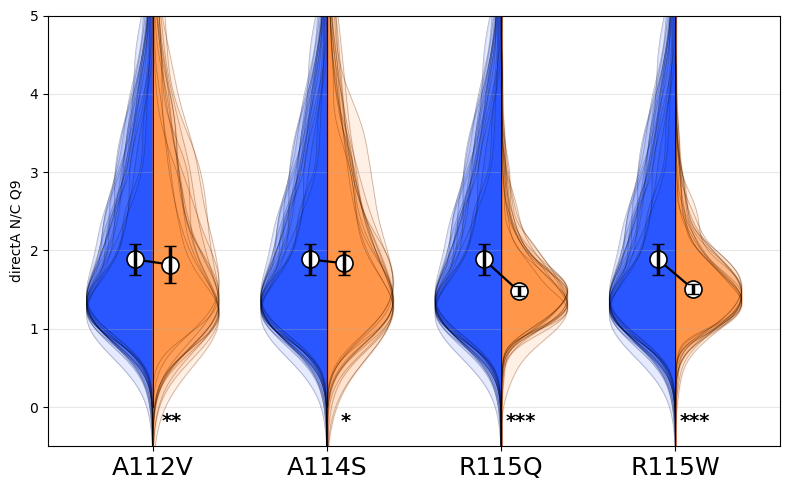

In [3]:

df['window']   = df['construct'].str.extract(r'^(\d+-\d+)_')
df['mutation'] = df['construct'].str.extract(r'^[\d-]+_(.+)$')
df['mut_pos']  = df['mutation'].str.extract(r'[A-Za-z](\d+)[A-Za-z]').astype(float)

wdf = df[df['window'] == '101-150'].copy()

mut_order = (wdf[wdf['mutation'] != 'WT']
             .groupby('mutation')['mut_pos']
             .first().reset_index()
             .sort_values('mut_pos')
             ['mutation'].tolist())

def get_by_well(sub_df, col='directA_N/C_Q9', min_pts=3):
    """Return list of value arrays, one per well (wells with <min_pts dropped)."""
    out = []
    for well, grp in sub_df.groupby('well'):
        v = grp[col].dropna().values
        if len(v) >= min_pts:
            out.append(v)
    return out

def half_violin_by_well(ax, pos, vals_by_well, side,
                        color, fill_alpha=0.1, half_width=0.38):
    all_vals = np.concatenate(vals_by_well) if vals_by_well else np.array([])
    if len(all_vals) < 4:
        return []

    pad    = max(np.std(all_vals) * 2.0, 0.3)
    y_lo   = max(all_vals.min() - pad, ax.get_ylim()[0])
    y_hi   = min(all_vals.max() + pad, ax.get_ylim()[1])
    y_grid = np.linspace(y_lo, y_hi, 400)

    well_medians = []
    for wv in vals_by_well:
        if len(wv) < 3:
            continue
        kde  = gaussian_kde(wv, bw_method='scott')
        dens = kde(y_grid)
        dens = dens / dens.max() * half_width

        if side == 'left':
            ax.fill_betweenx(y_grid, pos - dens, pos,
                             color=color, alpha=fill_alpha, linewidth=1)
            ax.plot(pos - dens, y_grid, color='black',
                    linewidth=0.5, alpha=fill_alpha + 0.15)
        else:
            ax.fill_betweenx(y_grid, pos, pos + dens,
                             color=color, alpha=fill_alpha, linewidth=1)
            ax.plot(pos + dens, y_grid, color='black',
                    linewidth=0.5, alpha=fill_alpha + 0.15)

        well_medians.append(np.median(wv))

    return well_medians   # ← replaces the old median bar

# ── Pre-group WT by well (same for every position) ───────────────────────────
wt_by_well = get_by_well(wdf[wdf['mutation'] == 'WT'])

from scipy.stats import mannwhitneyu

# ── Figure ────────────────────────────────────────────────────────────────────
n = len(mut_order)
fig, ax = plt.subplots(figsize=(max(8, n * 0.95), 5))
ax.set_ylim(-.5, 5)


# Pool all WT cells once for testing
wt_all = np.concatenate(wt_by_well) if wt_by_well else np.array([])

for i, mut in enumerate(mut_order):
    pos = i + 1
    mut_sub     = wdf[wdf['mutation'] == mut]
    mut_by_well = get_by_well(mut_sub)
    if not mut_by_well:
        continue

    wt_medians  = half_violin_by_well(ax, pos, wt_by_well,  side='left',  color='#0037FF')
    mut_medians = half_violin_by_well(ax, pos, mut_by_well, side='right', color='#FF730A')

    # Centre dividing line
    all_vals = np.concatenate(wt_by_well + mut_by_well)
    ax.plot([pos, pos], [all_vals.min() - 0.1, all_vals.max() + 0.1],
            color='black', linewidth=0.6, zorder=5)

    # ── Mean ± std of per-well medians ───────────────────────────────────────
    for medians, x_offset in [(wt_medians, -0.1), (mut_medians, 0.1)]:
        if len(medians) < 1:
            continue
        m   = np.mean(medians)
        err = np.std(medians) if len(medians) > 1 else 0

        # Error bar behind (no marker)
        ax.errorbar(pos + x_offset, m, yerr=err,
                    fmt='none',
                    ecolor='black', elinewidth=2.5, capsize=4,
                    zorder=8)

        # White dot on top
        ax.scatter([pos + x_offset], [m],
                   s=150, color='white',
                   edgecolors='black', linewidths=1.2,
                   zorder=7)

    # ── Line connecting WT mean to mutant mean ───────────────────────────────
    if wt_medians and mut_medians:
        wt_m  = np.mean(wt_medians)
        mut_m = np.mean(mut_medians)
        ax.plot([pos - 0.1, pos + 0.1], [wt_m, mut_m],
                color='black', linewidth=1.6, zorder=5, solid_capstyle='round')

    # ── Mann-Whitney U test ──────────────────────────────────────────────────
    mut_all = np.concatenate(mut_by_well)
    if len(wt_all) >= 3 and len(mut_all) >= 3:
        _, p = mannwhitneyu(wt_all, mut_all, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(pos + 0.11, -.3, sig, ha='center', va='bottom',
                fontsize=14, color='black', fontweight='bold')

ax.set_xticks(range(1, n + 1))
ax.set_xticklabels(mut_order, fontsize=18)
ax.set_xlim(0.4, n + 0.6)
ax.set_ylabel('directA N/C Q9')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('/Users/trev/Downloads/LocViolins.svg')
plt.show()

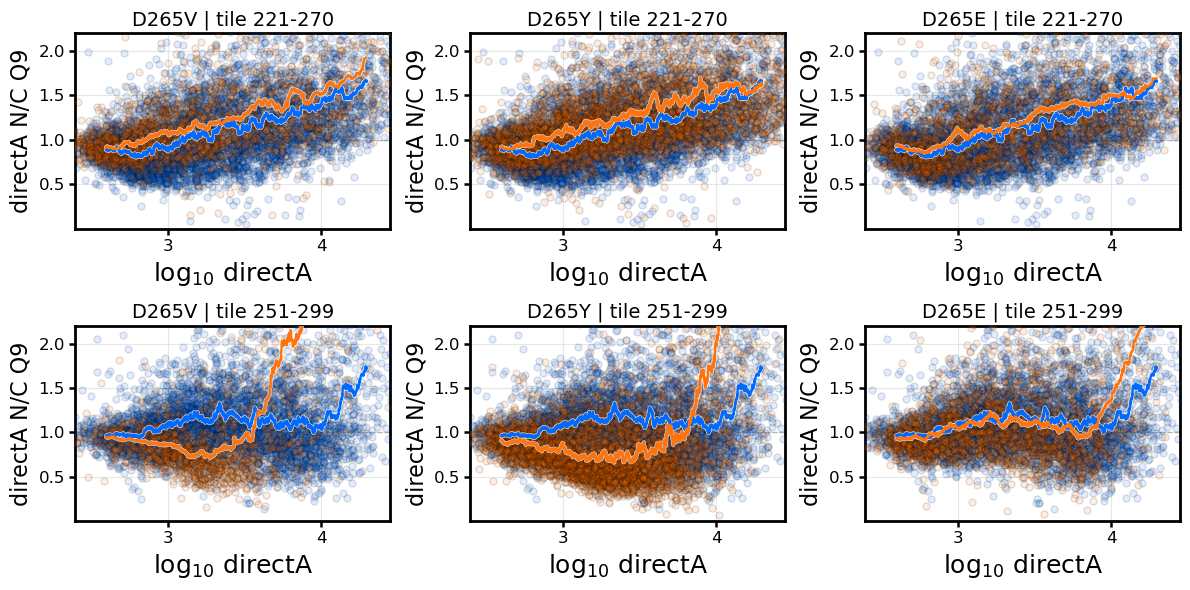

In [5]:
MUTANTS  = ['D265V', 'D265Y', 'D265E']
WINDOWS  = ['221-270', '251-299']
WT_COL   = '#006AFF'
MUT_COL  = '#FF730A'
ROLL_N   = 100
X_START, X_END = 2.6, 4.3

SUBPLOT_W, SUBPLOT_H = 4, 3

df1 = pd.read_csv('../Data/cells_concat_raw-1.csv')
df2 = pd.read_csv('../Data/cells_concat_raw-2.csv')
df_loc = pd.concat([df1, df2])
df_loc['window']   = df_loc['construct'].str.extract(r'^(\d+-\d+)_')
df_loc['mutation'] = df_loc['construct'].str.extract(r'^[\d-]+_(.+)$')

fig, axes = plt.subplots(
    len(WINDOWS), len(MUTANTS),
    figsize=(SUBPLOT_W * len(MUTANTS), SUBPLOT_H * len(WINDOWS)),
)

for row_idx, window in enumerate(WINDOWS):
    wdf = df_loc[df_loc['window'] == window].copy()

    for col_idx, mut in enumerate(MUTANTS):
        ax = axes[row_idx][col_idx]

        for vals, color, label in [
            (wdf[wdf['mutation'] == 'WT'], WT_COL,  'WT'),
            (wdf[wdf['mutation'] == mut],  MUT_COL, mut),
        ]:
            sub = vals[['log_directA_cell', 'directA_N/C_Q9']].dropna().copy()
            if sub.empty:
                continue

            ax.scatter(sub['log_directA_cell'], sub['directA_N/C_Q9'],
                       color=color, alpha=.12, s=25,
                       edgecolors='black', linewidths=1,
                       label=f'{label} (n={len(sub)})', zorder=3)

            sub_sorted = sub.sort_values('log_directA_cell')
            roll_y = sub_sorted['directA_N/C_Q9'].rolling(
                ROLL_N, center=True, min_periods=10).mean()
            clip_mask = (sub_sorted['log_directA_cell'] >= X_START) & \
                        (sub_sorted['log_directA_cell'] <= X_END)
            rx = sub_sorted.loc[clip_mask, 'log_directA_cell']
            ry = roll_y[clip_mask]

            ax.plot(rx, ry, color='white', linewidth=3, alpha=.6,
                    zorder=6, solid_capstyle='round')
            ax.plot(rx, ry, color=color, linewidth=1.7, alpha=1.0,
                    zorder=7, solid_capstyle='round')

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.set_xlim(2.4, 4.45)
        ax.set_ylim(0, 2.2)
        ax.set_yticks([0.5, 1.0, 1.5, 2.0])
        ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'], fontsize=12)
        ax.set_xticks([3, 4])
        ax.set_xticklabels(['3', '4'], fontsize=12)
        ax.tick_params(axis='both', which='both', width=1.8, length=4)
        ax.set_xlabel(r'log$_{10}$ directA', fontsize=18)
        ax.set_ylabel('directA N/C Q9', fontsize=16)
        ax.set_title(f'{mut} | tile {window}', fontsize=14)
        ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('/Users/trev/Downloads/intermolecularLoc.png', dpi=300)
plt.show()

In [6]:
df = df[df['directA_cell_max'] <= 65000] 

## Removing cells that are too circular (likely dying)
df = df[df['circ_cell_original'] < 0.7]
df = df[df['circ_cell_original'] > 0.3]
## Removing cells that have a very large nucleus in comparison to total area (likely dying), or they are segmented incorrectly (common in condensate formers)
df = df[df['nuc_area_ratio'] < .5]
df = df[df['nuc_area_ratio'] > .15]
## Removing cells with negative A_cell_corr - weird stuff going on or too close to background
df = df[df['A_cell_corr'] > 0]
## removing very small cells and/or debris
df = df[df['area_cell'] > 2000]
df = df[df['area_cell'] < 25000]

df = df[df['area_nuc'] < 5000]
df = df[df['area_nuc'] > 600]

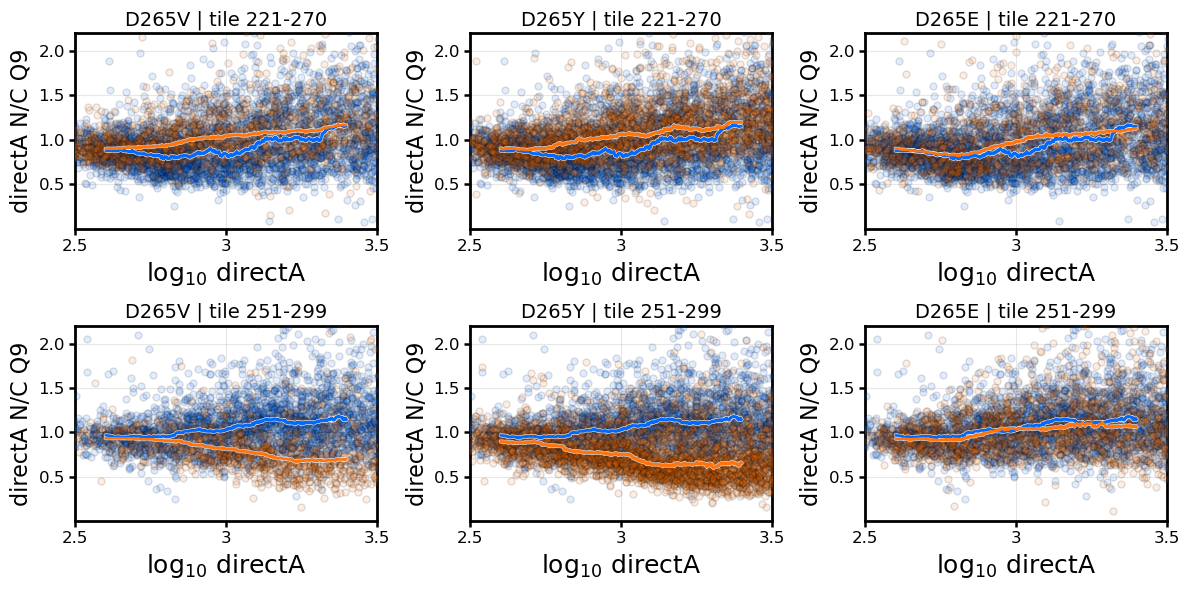

In [7]:
MUTANTS  = ['D265V', 'D265Y', 'D265E']
WINDOWS  = ['221-270', '251-299']
WT_COL   = '#006AFF'
MUT_COL  = '#FF730A'
ROLL_N   = 250
X_START, X_END = 2.6, 3.4

SUBPLOT_W, SUBPLOT_H = 4, 3

df1 = pd.read_csv('../Data/cells_concat_raw-1.csv')
df2 = pd.read_csv('../Data/cells_concat_raw-2.csv')
df_loc = pd.concat([df1, df2])
df_loc['window']   = df_loc['construct'].str.extract(r'^(\d+-\d+)_')
df_loc['mutation'] = df_loc['construct'].str.extract(r'^[\d-]+_(.+)$')

fig, axes = plt.subplots(
    len(WINDOWS), len(MUTANTS),
    figsize=(SUBPLOT_W * len(MUTANTS), SUBPLOT_H * len(WINDOWS)),
)

for row_idx, window in enumerate(WINDOWS):
    wdf = df_loc[df_loc['window'] == window].copy()

    for col_idx, mut in enumerate(MUTANTS):
        ax = axes[row_idx][col_idx]

        for vals, color, label in [
            (wdf[wdf['mutation'] == 'WT'], WT_COL,  'WT'),
            (wdf[wdf['mutation'] == mut],  MUT_COL, mut),
        ]:
            sub = vals[['log_directA_cell', 'directA_N/C_Q9']].dropna().copy()
            if sub.empty:
                continue

            ax.scatter(sub['log_directA_cell'], sub['directA_N/C_Q9'],
                       color=color, alpha=.12, s=25,
                       edgecolors='black', linewidths=1,
                       label=f'{label} (n={len(sub)})', zorder=3)

            sub_sorted = sub.sort_values('log_directA_cell')
            roll_y = sub_sorted['directA_N/C_Q9'].rolling(
                ROLL_N, center=True, min_periods=10).median()
            clip_mask = (sub_sorted['log_directA_cell'] >= X_START) & \
                        (sub_sorted['log_directA_cell'] <= X_END)
            rx = sub_sorted.loc[clip_mask, 'log_directA_cell']
            ry = roll_y[clip_mask]

            ax.plot(rx, ry, color='white', linewidth=3, alpha=.6,
                    zorder=6, solid_capstyle='round')
            ax.plot(rx, ry, color=color, linewidth=1.7, alpha=1.0,
                    zorder=7, solid_capstyle='round')

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.set_xlim(2.5, 3.5)
        ax.set_ylim(0, 2.2)
        ax.set_yticks([0.5, 1.0, 1.5, 2.0])
        ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'], fontsize=12)
        ax.set_xticks([2.5, 3, 3.5])
        ax.set_xticklabels(['2.5', '3', '3.5'], fontsize=12)
        ax.tick_params(axis='both', which='both', width=1.8, length=4)
        ax.set_xlabel(r'log$_{10}$ directA', fontsize=18)
        ax.set_ylabel('directA N/C Q9', fontsize=16)
        ax.set_title(f'{mut} | tile {window}', fontsize=14)
        ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('/Users/trev/Downloads/intermolecularLoc.png', dpi=300)
plt.show()

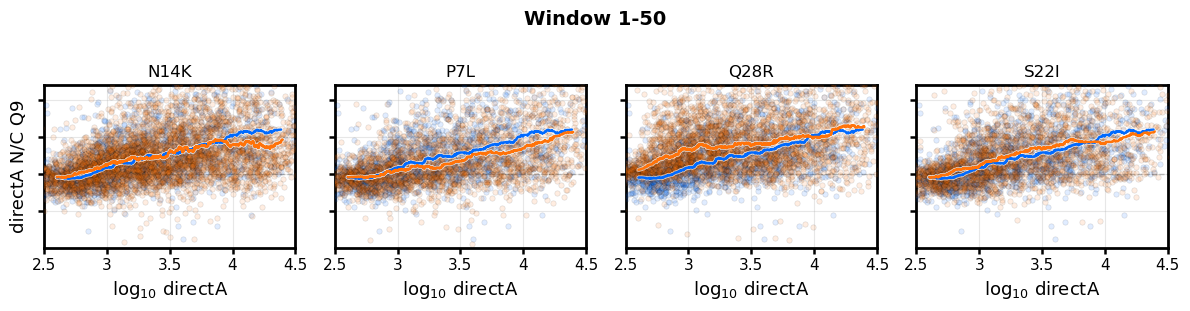

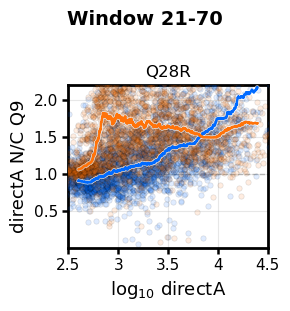

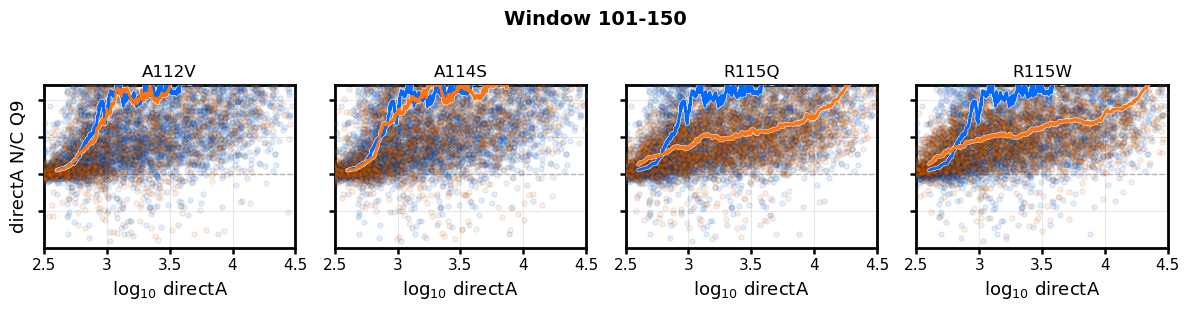

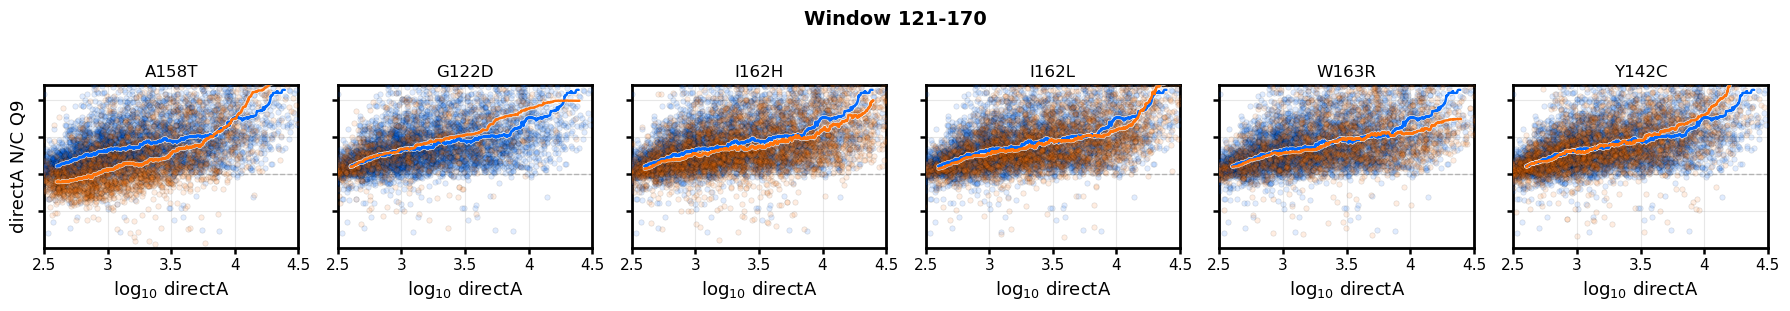

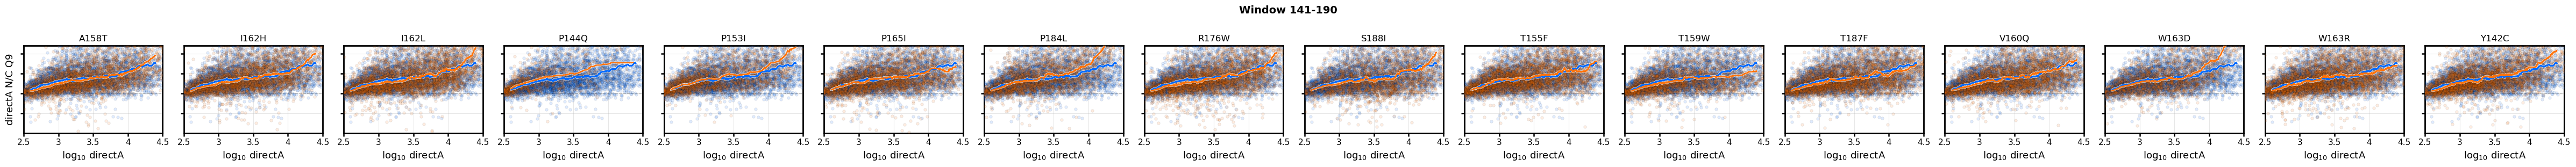

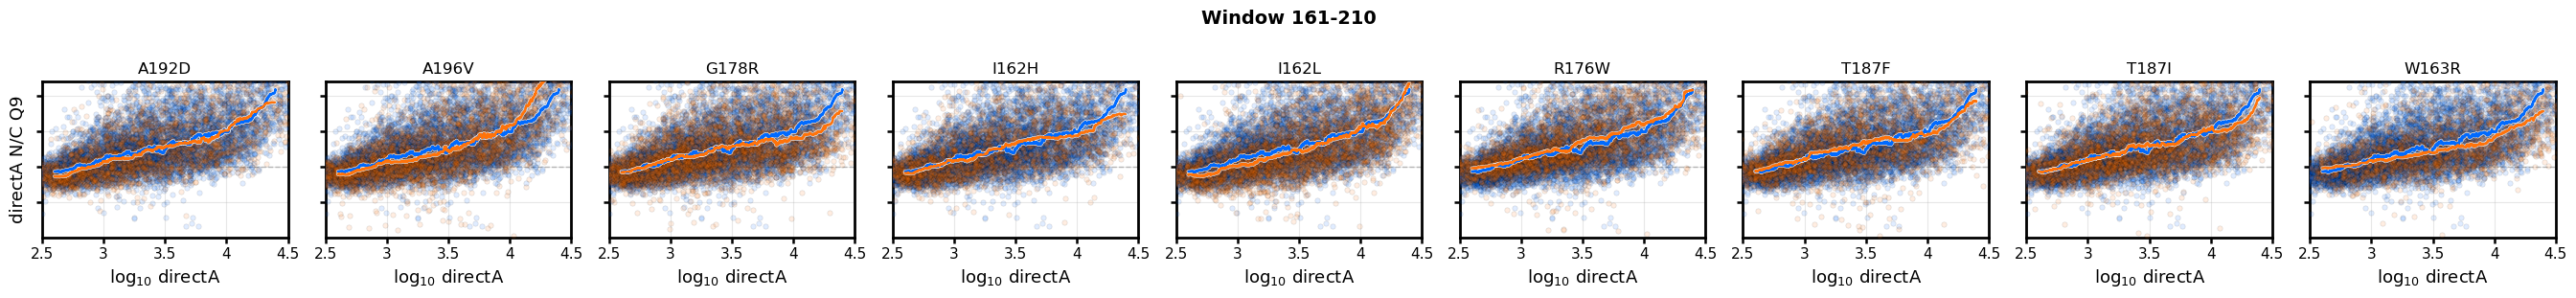

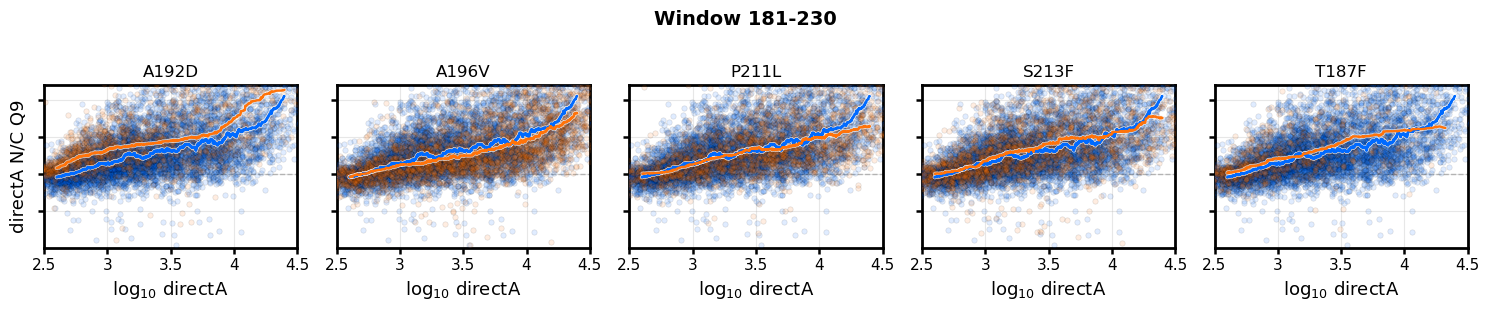

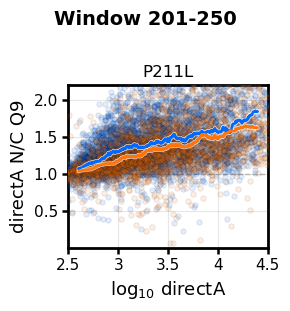

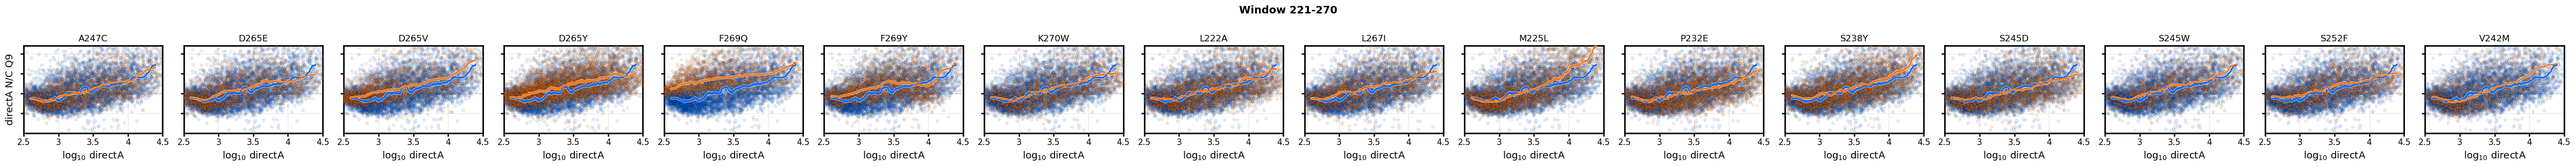

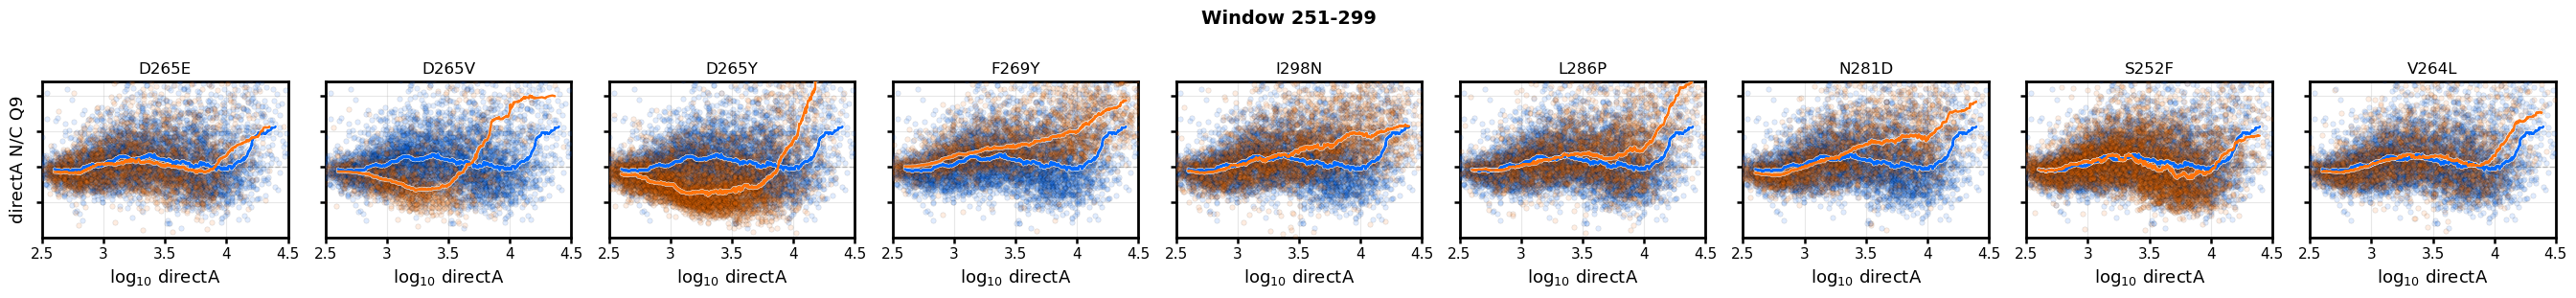

In [10]:
WT_COL  = '#006AFF'
MUT_COL = '#FF730A'
ROLL_N  = 250
X_START, X_END = 2.6, 4.4
SUBPLOT_W, SUBPLOT_H = 3, 3

df1 = pd.read_csv('../Data/cells_concat_raw-1.csv')
df2 = pd.read_csv('../Data/cells_concat_raw-2.csv')
df_loc = pd.concat([df1, df2])
df_loc['window']   = df_loc['construct'].str.extract(r'^(\d+-\d+)_')
df_loc['mutation'] = df_loc['construct'].str.extract(r'^[\d-]+_(.+)$')

# Get windows sorted numerically, mutants per window (excluding WT)
windows_sorted = sorted(df_loc['window'].dropna().unique(),
                        key=lambda w: int(w.split('-')[0]))

for window in windows_sorted:
    wdf = df_loc[df_loc['window'] == window].copy()
    mutants = sorted([m for m in wdf['mutation'].dropna().unique() if m != 'WT'])
    if not mutants:
        continue

    n_cols = len(mutants)
    fig, axes = plt.subplots(1, n_cols,
                             figsize=(SUBPLOT_W * n_cols, SUBPLOT_H),
                             sharey=True)
    if n_cols == 1:
        axes = [axes]

    fig.suptitle(f'Window {window}', fontsize=14, fontweight='bold', y=1.02)

    for col_idx, mut in enumerate(mutants):
        ax = axes[col_idx]

        for vals, color, label in [
            (wdf[wdf['mutation'] == 'WT'], WT_COL, 'WT'),
            (wdf[wdf['mutation'] == mut],  MUT_COL, mut),
        ]:
            sub = vals[['log_directA_cell', 'directA_N/C_Q9']].dropna().copy()
            if sub.empty:
                continue

            ax.scatter(sub['log_directA_cell'], sub['directA_N/C_Q9'],
                       color=color, alpha=.12, s=15,
                       edgecolors='black', linewidths=0.5,
                       label=f'{label} (n={len(sub)})', zorder=3)

            sub_sorted = sub.sort_values('log_directA_cell')
            roll_y = sub_sorted['directA_N/C_Q9'].rolling(
                ROLL_N, center=True, min_periods=10).median()
            clip_mask = (sub_sorted['log_directA_cell'] >= X_START) & \
                        (sub_sorted['log_directA_cell'] <= X_END)
            rx = sub_sorted.loc[clip_mask, 'log_directA_cell']
            ry = roll_y[clip_mask]

            if len(rx) > 0:
                ax.plot(rx, ry, color='white', linewidth=3, alpha=.6,
                        zorder=6, solid_capstyle='round')
                ax.plot(rx, ry, color=color, linewidth=1.7, alpha=1.0,
                        zorder=7, solid_capstyle='round')

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.set_xlim(2.5, 4.5)
        ax.set_ylim(0, 2.2)
        ax.set_yticks([0.5, 1.0, 1.5, 2.0])
        ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'] if col_idx == 0 else [], fontsize=11)
        ax.set_xticks([2.5, 3, 3.5, 4, 4.5])
        ax.set_xticklabels(['2.5', '3', '3.5', '4', '4.5'], fontsize=11)
        ax.tick_params(axis='both', which='both', width=1.8, length=4)
        ax.set_xlabel(r'log$_{10}$ directA', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('directA N/C Q9', fontsize=13)
        ax.set_title(mut, fontsize=12)
        ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()